# Opsi 3: Feature Augmentation (Input Baru untuk AI)

**Konsep Data-Centric:**
Meningkatkan akurasi prediksi AI dengan memberikan "penglihatan" tentang struktur mikro pasar melalui metrik topologi graf.

1.  **Graph Feature Engineering**: Setiap hari, kita membangun Correlation Graph dan mengekstrak metrik:
    -   **Graph_Density**: Kepadatan korelasi.
    -   **Average_Clustering**: Kecenderungan aset membentuk kelompok korelasi.
    -   **MIS_Size**: Ukuran Maximum Independent Set (Indikasi jumlah aset yang bergerak independen).
2.  **AI Enhanced Training**: Melatih Random Forest dengan fitur: `[Vol_20, Mom_20, Mom_50, Density, Clustering, MIS_Size]`.
3.  **Strategy Execution**: Mengandalkan akurasi AI yang telah ditingkatkan untuk sinyal Bull/Bear. Jika Bull, lakukan optimasi Markowitz pada seluruh aset.
4.  **Hipotesis**: AI akan lebih akurat mendeteksi pembalikan arah pasar (reversal) karena memahami perubahan struktur korelasi sebelum harga berubah drastis.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import os
from tqdm import tqdm

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

## 1. Data Loading

In [2]:
file_path = 'dataset_2023_2025.xlsx'
if os.path.exists(file_path):
    data = pd.read_excel(file_path, index_col=0, parse_dates=True)
else:
    print("File data tidak ditemukan!")
print(f"Data Shape: {data.shape}")

Data Shape: (990, 24)


## 2. Advanced Feature Engineering (Graph Metrics)
Menambahkan `MIS_Size` sebagai fitur tambahan.

In [3]:
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def calculate_graph_features(returns_df, window=30, threshold=0.5):
    densities = []
    clusterings = []
    mis_sizes = []
    dates = []
    
    print("Extracting Graph Features (including MIS_Size)...")
    for i in tqdm(range(window, len(returns_df))):
        window_data = returns_df.iloc[i-window:i]
        current_date = returns_df.index[i]
        
        corr_mat = window_data.corr().abs()
        G = nx.Graph()
        assets = window_data.columns
        G.add_nodes_from(assets)
        
        corr_values = corr_mat.values
        rows, cols = np.where(np.triu(corr_values, k=1) > threshold)
        edges = [(assets[r], assets[c]) for r, c in zip(rows, cols)]
        G.add_edges_from(edges)
        
        # Density
        densities.append(nx.density(G))
        # Clustering
        clusterings.append(nx.average_clustering(G))
        # MIS Size
        mis = nx.maximal_independent_set(G)
        mis_sizes.append(len(mis))
        
        dates.append(current_date)
        
    return pd.DataFrame({
        'Density': densities,
        'Clustering': clusterings,
        'MIS_Size': mis_sizes
    }, index=dates)

graph_features = calculate_graph_features(returns, window=30, threshold=0.5)

# Merge with Standard Features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features = features.join(graph_features).dropna()

features['Target'] = (market_return.shift(-1) > 0).astype(int)
features = features.dropna()

display(features.tail())

Extracting Graph Features (including MIS_Size)...


100%|██████████| 947/947 [00:00<00:00, 1161.79it/s]


,Vol_20,Mom_20,Mom_50,Density,Clustering,MIS_Size,Target
Date,,,,,,,
2025-12-27,0.023188,-0.000118,-0.002751,0.416667,0.644863,10.0,1
2025-12-28,0.021388,-0.001936,-0.002418,0.431159,0.653907,7.0,0
2025-12-29,0.020458,-0.003949,-0.003260,0.438406,0.648888,10.0,1
2025-12-30,0.020400,-0.003231,-0.003484,0.445652,0.649826,8.0,0
2025-12-31,0.020553,-0.003957,-0.002859,0.452899,0.690045,7.0,0


## 3. Train AI with Augmented Features

Opsi 3 AI Accuracy: 0.4603
              precision    recall  f1-score   support

           0       0.38      0.27      0.31       169
           1       0.50      0.63      0.56       196

    accuracy                           0.46       365
   macro avg       0.44      0.45      0.43       365
weighted avg       0.44      0.46      0.44       365



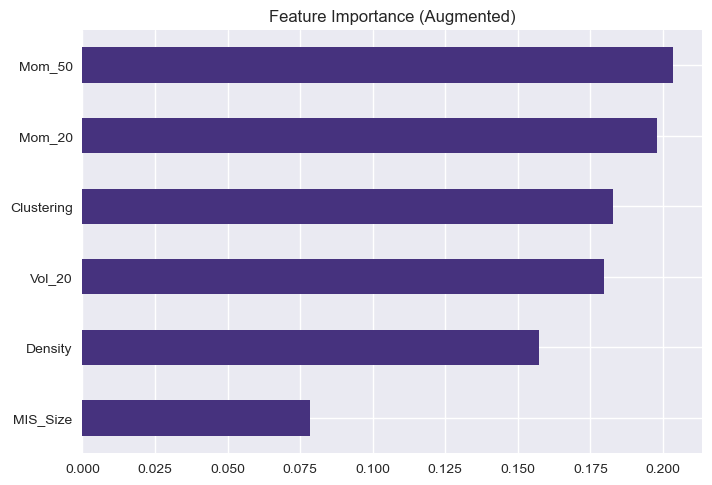

In [4]:
train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

# All features including Graph Metrics
feature_cols = ['Vol_20', 'Mom_20', 'Mom_50', 'Density', 'Clustering', 'MIS_Size']
X_train, y_train = features.loc[train_mask, feature_cols], features.loc[train_mask, 'Target']
X_test, y_test = features.loc[test_mask, feature_cols], features.loc[test_mask, 'Target']

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(f"Opsi 3 AI Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', title='Feature Importance (Augmented)')
plt.show()

## 4. Backtest (2025)

In [5]:
def optimize_markowitz(selected_assets_returns):
    mu = selected_assets_returns.mean() * 252
    sigma = selected_assets_returns.cov() * 252
    num_assets = len(mu)
    def neg_sharpe_ratio(weights):
        return -np.sum(weights * mu) / np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    result = minimize(neg_sharpe_ratio, num_assets*[1./num_assets], method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_assets_returns.columns, result.x))

initial_capital = 10000.0
current_value = initial_capital
history = []

test_probs = pd.Series(rf_model.predict_proba(X_test)[:, 1], index=X_test.index)

for i, date in enumerate(X_test.index):
    is_bull = test_probs.loc[date] > 0.5
    weights = {'CASH': 1.0}
    regime = "BEAR"
    
    if is_bull:
        regime = "BULL"
        loc_idx = returns.index.get_loc(date)
        window_returns = returns.iloc[loc_idx-30:loc_idx]
        weights = optimize_markowitz(window_returns)
    
    if i < len(X_test.index) - 1:
        next_date = X_test.index[i+1]
        daily_ret = 0
        if 'CASH' not in weights:
            for asset, w in weights.items():
                daily_ret += w * returns.loc[next_date, asset]
        
        current_value *= (1 + daily_ret)
        history.append({'Date': next_date, 'Value': current_value, 'Regime': regime})

perf_df = pd.DataFrame(history).set_index('Date')
print("Backtest Complete.")

Backtest Complete.


## 5. Visualisasi Hasil

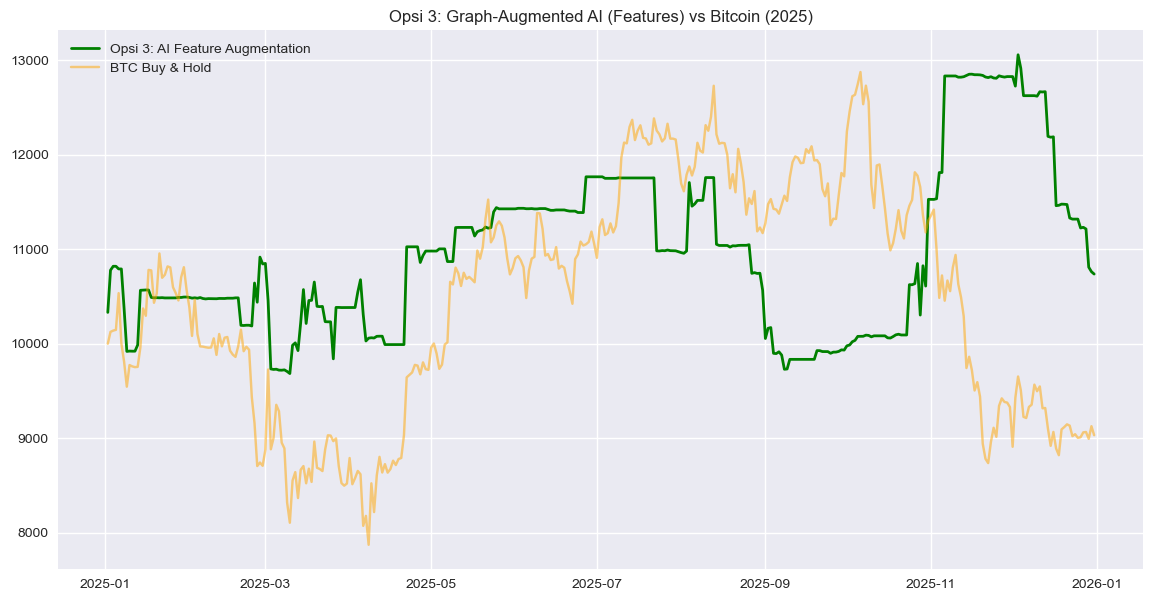

Final Return Opsi 3: 7.38%


In [6]:
btc_prices = data.loc[perf_df.index, 'BTC-USD']
btc_normalized = (btc_prices / btc_prices.iloc[0]) * initial_capital

plt.figure(figsize=(14, 7))
plt.plot(perf_df.index, perf_df['Value'], label='Opsi 3: AI Feature Augmentation', color='green', linewidth=2)
plt.plot(btc_normalized.index, btc_normalized, label='BTC Buy & Hold', color='orange', alpha=0.5)
plt.title('Opsi 3: Graph-Augmented AI (Features) vs Bitcoin (2025)')
plt.legend()
plt.show()

print(f"Final Return Opsi 3: {((perf_df['Value'].iloc[-1]/initial_capital)-1)*100:.2f}%")